In [66]:
import json
import pandas as pd

### JSON vs JSONL

- **JSON** stores one complete object or array in a single file.
- **JSONL** stores one JSON object per line, which is easier for streaming and large datasets.


In [67]:
import random
from datetime import datetime, timedelta
from uuid import uuid4

random.seed(42)

products = [
    ("B001", "Wireless Earbuds"),
    ("B002", "Stainless Steel Water Bottle"),
    ("B003", "Laptop Stand"),
    ("B004", "Coffee Maker"),
    ("B005", "Bluetooth Speaker"),
    ("B006", "Yoga Mat"),
    ("B007", "Desk Lamp"),
    ("B008", "Phone Case"),
    ("B009", "Backpack"),
    ("B010", "Mechanical Keyboard"),
]

review_phrases = [
    "excellent build quality",
    "works as expected",
    "good value for money",
    "easy to use",
    "highly recommended",
    "battery life could be better",
    "packaging was neat",
    "feels premium",
    "arrived on time",
    "customer support was helpful",
]

review_titles = [
    "Great product",
    "Worth buying",
    "Satisfied with purchase",
    "Could be better",
    "Amazing quality",
    "Solid choice",
    "Pretty decent",
    "Not bad at all",
]

start_date = datetime(2024, 1, 1)
reviews = []

for _ in range(100000):
    product_id, product_name = random.choice(products)
    rating = random.randint(1, 5)
    phrase = random.choice(review_phrases)
    title = random.choice(review_titles)
    review_date = start_date + timedelta(days=random.randint(0, 365))

    # Occasionally omit details (set to None) to simulate missing data
    if random.random() < 0.8:  # 80% records have details
        details = {
            "Date First Available": review_date.strftime("%B %d, %Y"),
            "Manufacturer": f"Brand {random.choice(['A', 'B', 'C', 'D'])}",
            "ASIN": f"ASIN{random.randint(1000000, 9999999)}",
        }
    else:
        details = None

    reviews.append(
        {
            "review_id": str(uuid4()),
            "product_id": product_id,
            "product_name": product_name,
            "reviewer_id": f"R{random.randint(100000, 999999)}",
            "rating": rating,
            "review_title": title,
            "review_text": f"This product has {phrase}. {title.lower()}.",
            "verified_purchase": random.choice([True, False]),
            "helpful_votes": random.randint(0, 50),
            "review_date": review_date.strftime("%Y-%m-%d"),
            "date": review_date.strftime("%Y-%m-%d"),
            "details": details,
        }
    )

reviews_df = pd.DataFrame(reviews)
reviews_df.head()


,review_id,product_id,product_name,reviewer_id,rating,review_title,review_text,verified_purchase,helpful_votes,review_date,date,details
0,c6a5f4e4-bd00-42c8-bc12-19949897b17c,B002,Stainless Steel Water Bottle,R719176,1,Could be better,This product has highly recommended. could be ...,False,2,2024-04-24,2024-04-24,"{'Date First Available': 'April 24, 2024', 'Ma..."
1,cc606b3c-bf82-4dd6-b102-f4ccfdabf0ea,B001,Wireless Earbuds,R331148,1,Could be better,This product has easy to use. could be better.,False,37,2024-09-15,2024-09-15,"{'Date First Available': 'September 15, 2024',..."
2,bf578c3c-a117-415c-867f-7f05dfa0c548,B005,Bluetooth Speaker,R207175,1,Pretty decent,This product has good value for money. pretty ...,True,24,2024-06-23,2024-06-23,"{'Date First Available': 'June 23, 2024', 'Man..."
3,f8988527-d565-48b3-ac54-d3d16aca0c6f,B002,Stainless Steel Water Bottle,R182627,3,Amazing quality,This product has battery life could be better....,False,40,2024-01-23,2024-01-23,"{'Date First Available': 'January 23, 2024', '..."
4,5951b9d1-28f3-447f-92b4-7d7aed294afd,B010,Mechanical Keyboard,R183667,3,Could be better,This product has customer support was helpful....,True,6,2024-12-26,2024-12-26,"{'Date First Available': 'December 26, 2024', ..."


In [68]:
from pathlib import Path

output_path = Path('/Users/kishorkumarparoi/Desktop/Maven - The AI Engineering Bootcamp /Resources/AIE5-main/20_RAG_Pipeline/data/data.jsonl')

with output_path.open('w', encoding='utf-8') as file_handle:
    for record in reviews:
        file_handle.write(json.dumps(record) + '\n')

print(f'Wrote {len(reviews)} reviews to {output_path}')


Wrote 100000 reviews to /Users/kishorkumarparoi/Desktop/Maven - The AI Engineering Bootcamp /Resources/AIE5-main/20_RAG_Pipeline/data/data.jsonl


In [69]:
with open('../data/data.jsonl', 'r', encoding='utf-8') as file_handle:
    for _ in range(5):
        line = file_handle.readline()
        review_record = json.loads(line)
        print(review_record)

{'review_id': 'c6a5f4e4-bd00-42c8-bc12-19949897b17c', 'product_id': 'B002', 'product_name': 'Stainless Steel Water Bottle', 'reviewer_id': 'R719176', 'rating': 1, 'review_title': 'Could be better', 'review_text': 'This product has highly recommended. could be better.', 'verified_purchase': False, 'helpful_votes': 2, 'review_date': '2024-04-24', 'date': '2024-04-24', 'details': {'Date First Available': 'April 24, 2024', 'Manufacturer': 'Brand A', 'ASIN': 'ASIN2458591'}}
{'review_id': 'cc606b3c-bf82-4dd6-b102-f4ccfdabf0ea', 'product_id': 'B001', 'product_name': 'Wireless Earbuds', 'reviewer_id': 'R331148', 'rating': 1, 'review_title': 'Could be better', 'review_text': 'This product has easy to use. could be better.', 'verified_purchase': False, 'helpful_votes': 37, 'review_date': '2024-09-15', 'date': '2024-09-15', 'details': {'Date First Available': 'September 15, 2024', 'Manufacturer': 'Brand B', 'ASIN': 'ASIN8038374'}}
{'review_id': 'bf578c3c-a117-415c-867f-7f05dfa0c548', 'product_id'

In [70]:
with open('../data/data.jsonl', 'r', encoding='utf-8') as file_handle:
   first_line = json.loads(file_handle.readline())

In [71]:
first_line

{'review_id': 'c6a5f4e4-bd00-42c8-bc12-19949897b17c',
 'product_id': 'B002',
 'product_name': 'Stainless Steel Water Bottle',
 'reviewer_id': 'R719176',
 'rating': 1,
 'review_title': 'Could be better',
 'review_text': 'This product has highly recommended. could be better.',
 'verified_purchase': False,
 'helpful_votes': 2,
 'review_date': '2024-04-24',
 'date': '2024-04-24',
 'details': {'Date First Available': 'April 24, 2024',
  'Manufacturer': 'Brand A',
  'ASIN': 'ASIN2458591'}}

Filter Items that has been observed first item after 2022

In [72]:
def filter_data(data: dict) -> bool:
    try:
        date_str = data.get("details", {}).get("Date First Available", "")
        if date_str:
            datetime.strptime(date_str, "%B %d, %Y")
            return True
        else:
            return False
    except ValueError:
        pass
    return False

In [73]:
with open('../data/data.jsonl', 'r', encoding='utf-8') as fp:
    with open('../data/Data_With_Details.jsonl', 'w', encoding='utf-8') as fp_out:
        with open('../data/Data_With_No_Details.jsonl', 'w', encoding='utf-8') as fp_no_details:
            i = 0
            for line in fp:
                data = json.loads(line.strip())
                try:
                    should_skip = filter_data(data)
                    if not should_skip:
                        json.dump(data, fp_out)
                        fp_out.write('\n')
                        fp_out.flush()
                except Exception:
                    json.dump(data, fp_no_details)
                    fp_no_details.write('\n')
                    fp_no_details.flush()

                i += 1
                if i % 1000 == 0:
                    print(f"Processed {i} lines")


Processed 1000 lines
Processed 2000 lines
Processed 3000 lines
Processed 4000 lines
Processed 5000 lines
Processed 6000 lines
Processed 7000 lines
Processed 8000 lines
Processed 9000 lines
Processed 10000 lines
Processed 11000 lines
Processed 12000 lines
Processed 13000 lines
Processed 14000 lines
Processed 15000 lines
Processed 16000 lines
Processed 17000 lines
Processed 18000 lines
Processed 19000 lines
Processed 20000 lines
Processed 21000 lines
Processed 22000 lines
Processed 23000 lines
Processed 24000 lines
Processed 25000 lines
Processed 26000 lines
Processed 27000 lines
Processed 28000 lines
Processed 29000 lines
Processed 30000 lines
Processed 31000 lines
Processed 32000 lines
Processed 33000 lines
Processed 34000 lines
Processed 35000 lines
Processed 36000 lines
Processed 37000 lines
Processed 38000 lines
Processed 39000 lines
Processed 40000 lines
Processed 41000 lines
Processed 42000 lines
Processed 43000 lines
Processed 44000 lines
Processed 45000 lines
Processed 46000 lin

In [74]:
with open('../data/data.jsonl', 'r', encoding='utf-8') as fp, \
     open('../data/Data_With_Details.jsonl', 'w', encoding='utf-8') as fp_out, \
     open('../data/Data_No_details.jsonl', 'w', encoding='utf-8') as fp_no_date, \
     open('../data/Data_With_Details_After_2022.jsonl', 'w', encoding='utf-8') as fp_after_2022:
    i = 0
    for line in fp:
        data = json.loads(line.strip())
        i += 1
        details = data.get("details")
        # Records without details -> separate file
        if not details:
            json.dump(data, fp_no_date)
            fp_no_date.write('\n')
            fp_no_date.flush()
            continue
        # Write all records that have details
        json.dump(data, fp_out)
        fp_out.write('\n')
        fp_out.flush()
        # Optional: also write records observed after 2022 to a separate file
        date_str = details.get('Date First Available', '')
        try:
            year = int(date_str.strip()[-4:]) if len(date_str) >= 4 else None
        except Exception:
            year = None
        if year and year > 2022:
            json.dump(data, fp_after_2022)
            fp_after_2022.write('\n')
            fp_after_2022.flush()
        if i % 1000 == 0:
            print(f"Processed {i} lines")

Processed 1000 lines
Processed 2000 lines
Processed 3000 lines
Processed 5000 lines
Processed 8000 lines
Processed 9000 lines
Processed 10000 lines
Processed 11000 lines
Processed 12000 lines
Processed 13000 lines
Processed 14000 lines
Processed 16000 lines
Processed 17000 lines
Processed 18000 lines
Processed 19000 lines
Processed 20000 lines
Processed 21000 lines
Processed 23000 lines
Processed 24000 lines
Processed 25000 lines
Processed 26000 lines
Processed 27000 lines
Processed 29000 lines
Processed 31000 lines
Processed 32000 lines
Processed 34000 lines
Processed 35000 lines
Processed 38000 lines
Processed 39000 lines
Processed 40000 lines
Processed 41000 lines
Processed 42000 lines
Processed 43000 lines
Processed 44000 lines
Processed 45000 lines
Processed 47000 lines
Processed 48000 lines
Processed 49000 lines
Processed 50000 lines
Processed 51000 lines
Processed 52000 lines
Processed 53000 lines
Processed 54000 lines
Processed 55000 lines
Processed 56000 lines
Processed 58000 

In [75]:
df = pd.read_json('../data/Data_With_Details.jsonl', lines=True)
print(df.head())

                              review_id product_id  \
0  c6a5f4e4-bd00-42c8-bc12-19949897b17c       B002   
1  cc606b3c-bf82-4dd6-b102-f4ccfdabf0ea       B001   
2  bf578c3c-a117-415c-867f-7f05dfa0c548       B005   
3  f8988527-d565-48b3-ac54-d3d16aca0c6f       B002   
4  5951b9d1-28f3-447f-92b4-7d7aed294afd       B010   

                   product_name reviewer_id  rating     review_title  \
0  Stainless Steel Water Bottle     R719176       1  Could be better   
1              Wireless Earbuds     R331148       1  Could be better   
2             Bluetooth Speaker     R207175       1    Pretty decent   
3  Stainless Steel Water Bottle     R182627       3  Amazing quality   
4           Mechanical Keyboard     R183667       3  Could be better   

                                         review_text  verified_purchase  \
0  This product has highly recommended. could be ...              False   
1     This product has easy to use. could be better.              False   
2  This product h

<Axes: xlabel='helpful_votes'>

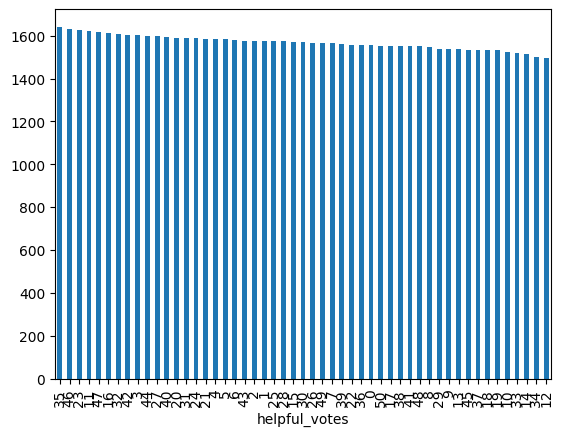

In [76]:
df['helpful_votes'].value_counts().plot(kind='bar')

In [77]:
df.head()

,review_id,product_id,product_name,reviewer_id,rating,review_title,review_text,verified_purchase,helpful_votes,review_date,date,details
0,c6a5f4e4-bd00-42c8-bc12-19949897b17c,B002,Stainless Steel Water Bottle,R719176,1,Could be better,This product has highly recommended. could be ...,False,2,2024-04-24,2024-04-24,"{'Date First Available': 'April 24, 2024', 'Ma..."
1,cc606b3c-bf82-4dd6-b102-f4ccfdabf0ea,B001,Wireless Earbuds,R331148,1,Could be better,This product has easy to use. could be better.,False,37,2024-09-15,2024-09-15,"{'Date First Available': 'September 15, 2024',..."
2,bf578c3c-a117-415c-867f-7f05dfa0c548,B005,Bluetooth Speaker,R207175,1,Pretty decent,This product has good value for money. pretty ...,True,24,2024-06-23,2024-06-23,"{'Date First Available': 'June 23, 2024', 'Man..."
3,f8988527-d565-48b3-ac54-d3d16aca0c6f,B002,Stainless Steel Water Bottle,R182627,3,Amazing quality,This product has battery life could be better....,False,40,2024-01-23,2024-01-23,"{'Date First Available': 'January 23, 2024', '..."
4,5951b9d1-28f3-447f-92b4-7d7aed294afd,B010,Mechanical Keyboard,R183667,3,Could be better,This product has customer support was helpful....,True,6,2024-12-26,2024-12-26,"{'Date First Available': 'December 26, 2024', ..."


<Axes: xlabel='rating'>

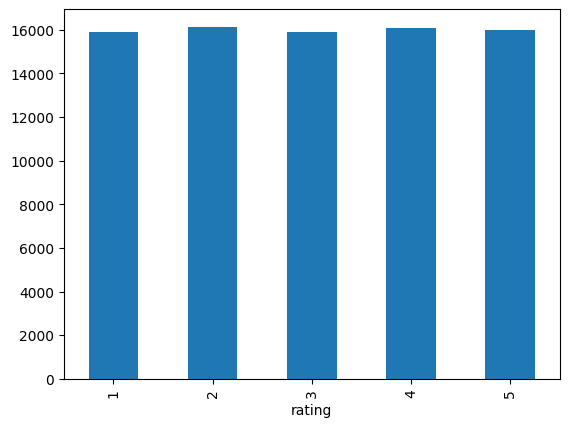

In [78]:
df_ratings = df['rating'].value_counts().sort_index()
df_ratings.plot(kind='bar')

In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 79996 entries, 0 to 79995
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   review_id          79996 non-null  str           
 1   product_id         79996 non-null  str           
 2   product_name       79996 non-null  str           
 3   reviewer_id        79996 non-null  str           
 4   rating             79996 non-null  int64         
 5   review_title       79996 non-null  str           
 6   review_text        79996 non-null  str           
 7   verified_purchase  79996 non-null  bool          
 8   helpful_votes      79996 non-null  int64         
 9   review_date        79996 non-null  str           
 10  date               79996 non-null  datetime64[us]
 11  details            79996 non-null  object        
dtypes: bool(1), datetime64[us](1), int64(2), object(1), str(7)
memory usage: 6.8+ MB
